In [4]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [5]:
from tkinter import Tk, filedialog

Tk().withdraw()

validation_path = filedialog.askopenfilename(
    title="5x64x64_validation_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Selected file:")
print(validation_path)

Selected file:
C:/Users/ancha/Downloads/5x64x64_validation_with_morphology.hdf5


In [6]:
# Load 1D metadata features from the validation HDF5 file
# The large image dataset is excluded

validation_metadata = {}

with h5py.File(validation_path, "r") as f:
    for key in f.keys():
        if key == "image":
            continue
        
        if len(f[key].shape) == 1:
            validation_metadata[key] = f[key][:]

df_val = pd.DataFrame(validation_metadata)

print("Validation dataset shape:", df_val.shape)
print("Number of galaxies:", len(df_val))
print("Number of features:", len(df_val.columns))

Validation dataset shape: (40914, 84)
Number of galaxies: 40914
Number of features: 84


In [7]:
# Display the structure and data types of the validation dataset

df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40914 entries, 0 to 40913
Data columns (total 84 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   coord                         40914 non-null  object 
 1   dec                           40914 non-null  float64
 2   g_central_image_pop_10px_rad  40914 non-null  int64  
 3   g_central_image_pop_15px_rad  40914 non-null  int64  
 4   g_central_image_pop_5px_rad   40914 non-null  int64  
 5   g_cmodel_mag                  40914 non-null  float64
 6   g_cmodel_magsigma             40914 non-null  float64
 7   g_ellipticity                 40914 non-null  float64
 8   g_half_light_radius           40914 non-null  float64
 9   g_isophotal_area              40914 non-null  float64
 10  g_major_axis                  40914 non-null  float64
 11  g_minor_axis                  40914 non-null  float64
 12  g_peak_surface_brightness     40914 non-null  float64
 13  g

In [8]:
# Display the structure and data types of the validation dataset

df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40914 entries, 0 to 40913
Data columns (total 84 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   coord                         40914 non-null  object 
 1   dec                           40914 non-null  float64
 2   g_central_image_pop_10px_rad  40914 non-null  int64  
 3   g_central_image_pop_15px_rad  40914 non-null  int64  
 4   g_central_image_pop_5px_rad   40914 non-null  int64  
 5   g_cmodel_mag                  40914 non-null  float64
 6   g_cmodel_magsigma             40914 non-null  float64
 7   g_ellipticity                 40914 non-null  float64
 8   g_half_light_radius           40914 non-null  float64
 9   g_isophotal_area              40914 non-null  float64
 10  g_major_axis                  40914 non-null  float64
 11  g_minor_axis                  40914 non-null  float64
 12  g_peak_surface_brightness     40914 non-null  float64
 13  g

In [9]:
# Display all column names

print("Columns:")
for col in df_val.columns:
    print(col)

Columns:
coord
dec
g_central_image_pop_10px_rad
g_central_image_pop_15px_rad
g_central_image_pop_5px_rad
g_cmodel_mag
g_cmodel_magsigma
g_ellipticity
g_half_light_radius
g_isophotal_area
g_major_axis
g_minor_axis
g_peak_surface_brightness
g_petro_rad
g_pos_angle
g_sersic_index
i_central_image_pop_10px_rad
i_central_image_pop_15px_rad
i_central_image_pop_5px_rad
i_cmodel_mag
i_cmodel_magsigma
i_ellipticity
i_half_light_radius
i_isophotal_area
i_major_axis
i_minor_axis
i_peak_surface_brightness
i_petro_rad
i_pos_angle
i_sersic_index
object_id
r_central_image_pop_10px_rad
r_central_image_pop_15px_rad
r_central_image_pop_5px_rad
r_cmodel_mag
r_cmodel_magsigma
r_ellipticity
r_half_light_radius
r_isophotal_area
r_major_axis
r_minor_axis
r_peak_surface_brightness
r_petro_rad
r_pos_angle
r_sersic_index
ra
skymap_id
specz_dec
specz_flag_homogeneous
specz_mag_i
specz_name
specz_ra
specz_redshift
specz_redshift_err
x_coord
y_central_image_pop_10px_rad
y_central_image_pop_15px_rad
y_central_image_

In [10]:
# Check for missing values in the validation dataset

missing_val = df_val.isnull().sum()

print("Total missing values:", missing_val.sum())

missing_val = missing_val[missing_val > 0]

display(missing_val)

Total missing values: 0


Series([], dtype: int64)

In [11]:
# Check for missing values in the validation dataset

missing_val = df_val.isnull().sum()

print("Total missing values:", missing_val.sum())

missing_val = missing_val[missing_val > 0]

display(missing_val)

Total missing values: 0


Series([], dtype: int64)

In [12]:
# Check for infinite values in numerical features

numeric_val = df_val.select_dtypes(include=np.number)

inf_values_val = np.isinf(numeric_val).sum().sum()

print("Infinite values:", inf_values_val)

Infinite values: 0


In [13]:
# Generate descriptive statistics for the validation dataset

summary_val = df_val.describe().T

display(summary_val)

,count,mean,std,min,25%,50%,75%,max
dec,40914.0,4.623619,14.597552,-7.212280,-0.975744,0.302766,1.677525,53.247326
g_central_image_pop_10px_rad,40914.0,1.016669,0.201104,0.000000,1.000000,1.000000,1.000000,3.000000
g_central_image_pop_15px_rad,40914.0,1.033509,0.241344,0.000000,1.000000,1.000000,1.000000,5.000000
g_central_image_pop_5px_rad,40914.0,0.999267,0.159740,0.000000,1.000000,1.000000,1.000000,3.000000
g_cmodel_mag,40914.0,21.249133,1.882792,14.659384,19.719701,21.495157,22.626182,28.930138
...,...,...,...,...,...,...,...,...
z_minor_axis,40914.0,4.076967,2.154233,0.000000,2.320000,3.740000,5.258000,15.113000
z_peak_surface_brightness,40914.0,-6.824209,1.421993,-10.643900,-7.833500,-7.004450,-5.942900,0.000000
z_petro_rad,40914.0,6.250427,1.409411,0.000000,5.280000,5.940000,6.600000,10.560000
z_pos_angle,40914.0,1.701474,52.304183,-90.000000,-44.010000,3.280000,47.200000,89.980000


In [14]:
# Display minimum, maximum, mean and standard deviation

display(summary_val[['min', 'max', 'mean', 'std']])

,min,max,mean,std
dec,-7.212280,53.247326,4.623619,14.597552
g_central_image_pop_10px_rad,0.000000,3.000000,1.016669,0.201104
g_central_image_pop_15px_rad,0.000000,5.000000,1.033509,0.241344
g_central_image_pop_5px_rad,0.000000,3.000000,0.999267,0.159740
g_cmodel_mag,14.659384,28.930138,21.249133,1.882792
...,...,...,...,...
z_minor_axis,0.000000,15.113000,4.076967,2.154233
z_peak_surface_brightness,-10.643900,0.000000,-6.824209,1.421993
z_petro_rad,0.000000,10.560000,6.250427,1.409411
z_pos_angle,-90.000000,89.980000,1.701474,52.304183


In [15]:
#Important Astronomical Features

In [16]:
# Select important photometric and morphological features

bands = ["g", "r", "i", "z", "y"]

important_features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    
    "g_ellipticity",
    "r_ellipticity",
    "i_ellipticity",
    "z_ellipticity",
    "y_ellipticity",
    
    "g_half_light_radius",
    "r_half_light_radius",
    "i_half_light_radius",
    "z_half_light_radius",
    "y_half_light_radius",
    
    "g_sersic_index",
    "r_sersic_index",
    "i_sersic_index",
    "z_sersic_index",
    "y_sersic_index",
    
    "specz_redshift"
]

display(df_val[important_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
g_cmodel_mag,40914.0,21.249133,1.882792,14.659384,19.719701,21.495157,22.626182,28.930138
r_cmodel_mag,40914.0,20.232683,1.872943,14.206667,18.765399,20.296591,21.555106,26.762321
i_cmodel_mag,40914.0,19.617592,1.839216,13.992483,18.253001,19.490281,20.970790,26.123264
z_cmodel_mag,40914.0,19.308207,1.839524,13.808403,17.963008,19.122225,20.688778,25.763508
y_cmodel_mag,40914.0,19.136310,1.860543,13.545700,17.779293,18.928122,20.537897,27.253254
g_ellipticity,40914.0,0.230968,0.171884,0.000000,0.096000,0.190000,0.328000,0.882000
r_ellipticity,40914.0,0.232309,0.168773,0.000000,0.099000,0.194000,0.327000,0.884000
i_ellipticity,40914.0,0.243434,0.171292,0.000000,0.107000,0.209000,0.343000,0.885000
z_ellipticity,40914.0,0.232025,0.167277,0.000000,0.100000,0.195000,0.326000,0.890000
y_ellipticity,40914.0,0.227176,0.165692,0.000000,0.097000,0.189000,0.319000,0.887000


In [ ]:
#Redshift Distribution

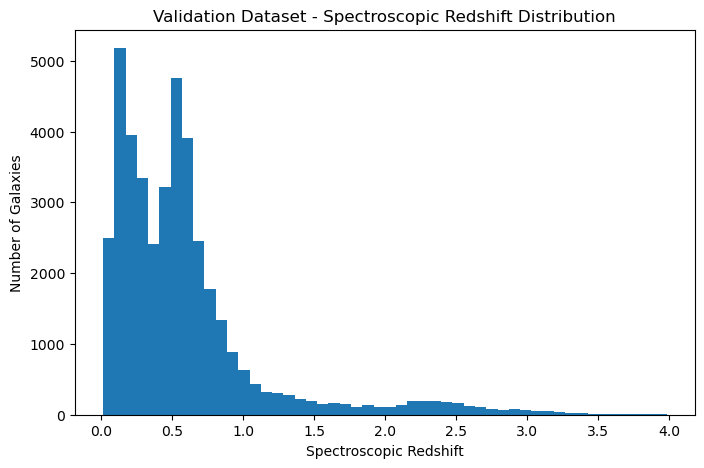

In [17]:
# Plot the distribution of spectroscopic redshift

plt.figure(figsize=(8,5))

plt.hist(
    df_val["specz_redshift"].dropna(),
    bins=50
)

plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Number of Galaxies")
plt.title("Validation Dataset - Spectroscopic Redshift Distribution")

plt.show()

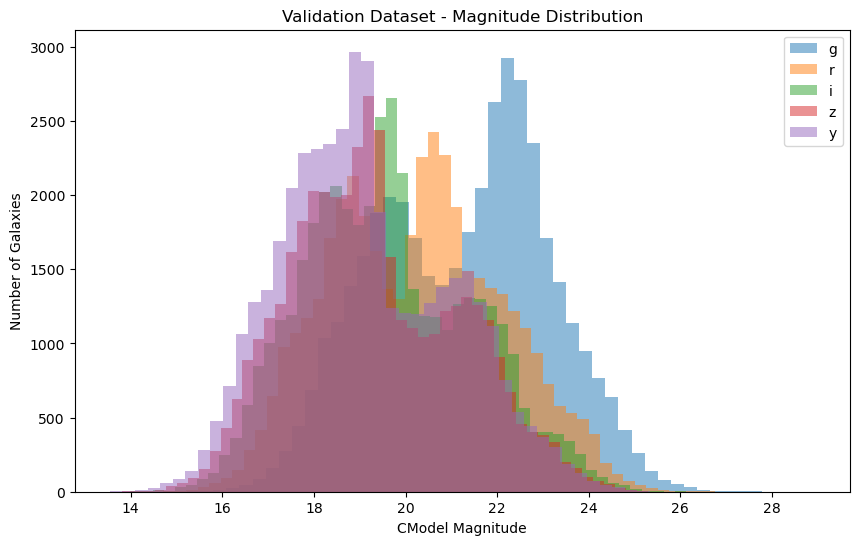

In [18]:
# Compare CModel magnitude distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_val[f"{band}_cmodel_mag"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("CModel Magnitude")
plt.ylabel("Number of Galaxies")
plt.title("Validation Dataset - Magnitude Distribution")
plt.legend()

plt.show()

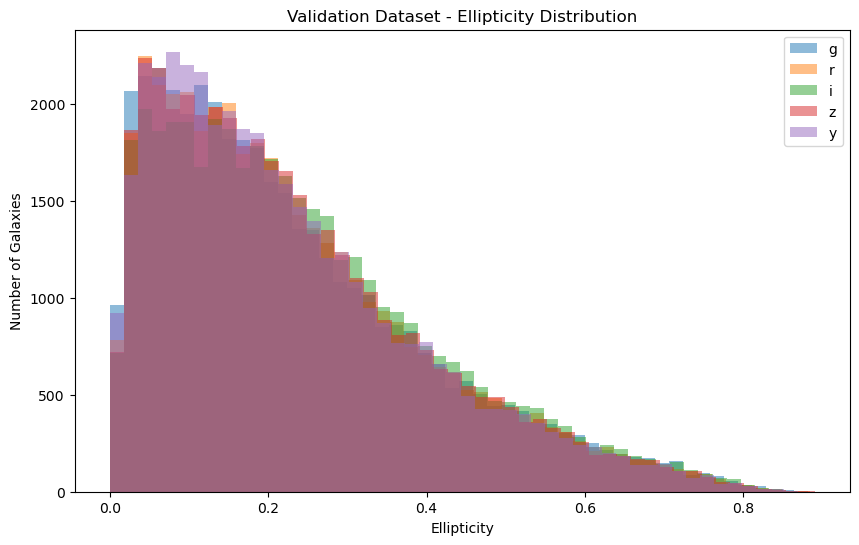

In [20]:
# Compare ellipticity distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_val[f"{band}_ellipticity"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("Ellipticity")
plt.ylabel("Number of Galaxies")
plt.title("Validation Dataset - Ellipticity Distribution")
plt.legend()

plt.show()

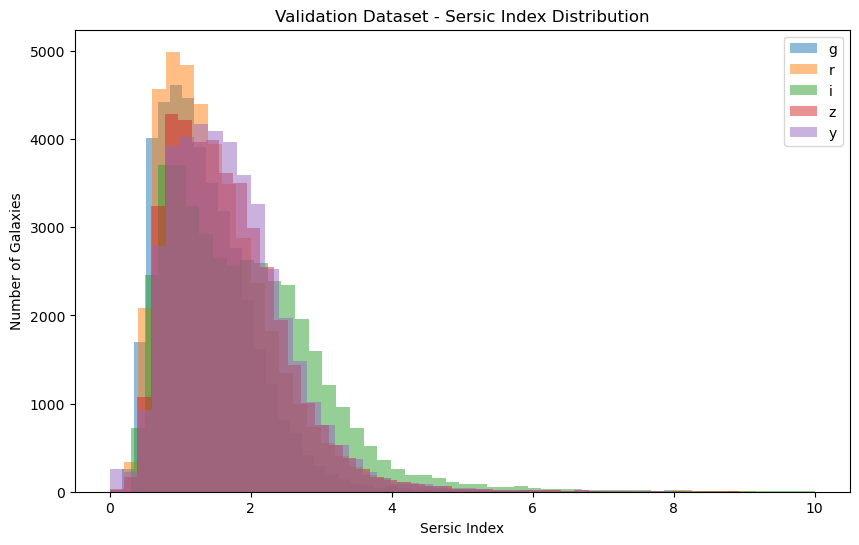

In [21]:
# Compare Sersic index distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_val[f"{band}_sersic_index"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("Sersic Index")
plt.ylabel("Number of Galaxies")
plt.title("Validation Dataset - Sersic Index Distribution")
plt.legend()

plt.show()

C:\Users\ancha\AppData\Local\Temp\ipykernel_23812\1925991215.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


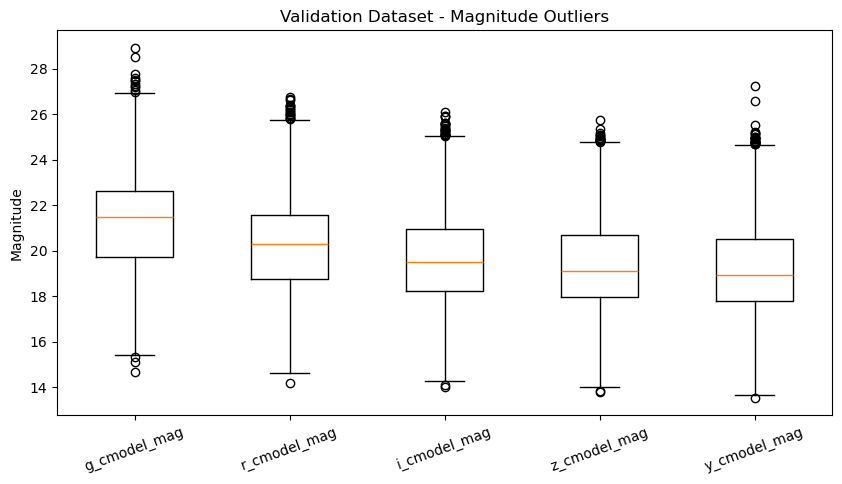

In [22]:
# Use boxplots to identify potential outliers in galaxy magnitudes

magnitude_cols = [f"{b}_cmodel_mag" for b in bands]

plt.figure(figsize=(10,5))

plt.boxplot(
    [df_val[col] for col in magnitude_cols],
    labels=magnitude_cols
)

plt.xticks(rotation=20)
plt.ylabel("Magnitude")
plt.title("Validation Dataset - Magnitude Outliers")

plt.show()

C:\Users\ancha\AppData\Local\Temp\ipykernel_23812\1727169587.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


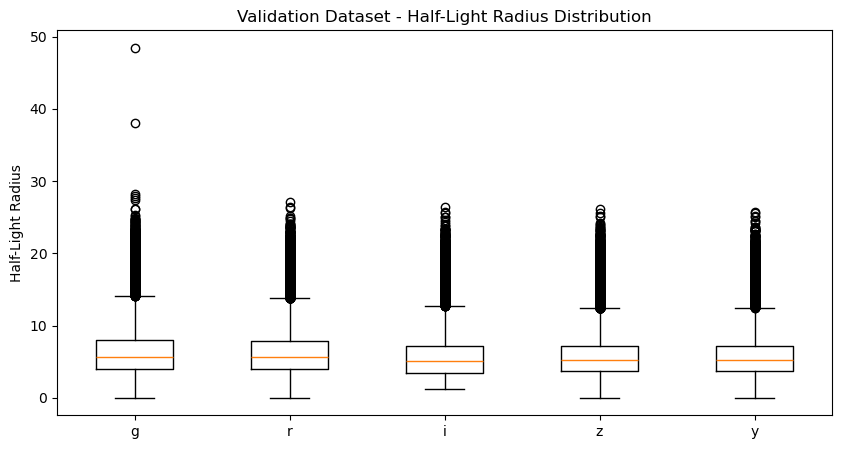

In [23]:
# Use boxplots to identify potential outliers in half-light radius

radius_cols = [f"{b}_half_light_radius" for b in bands]

plt.figure(figsize=(10,5))

plt.boxplot(
    [df_val[col] for col in radius_cols],
    labels=bands
)

plt.ylabel("Half-Light Radius")
plt.title("Validation Dataset - Half-Light Radius Distribution")

plt.show()

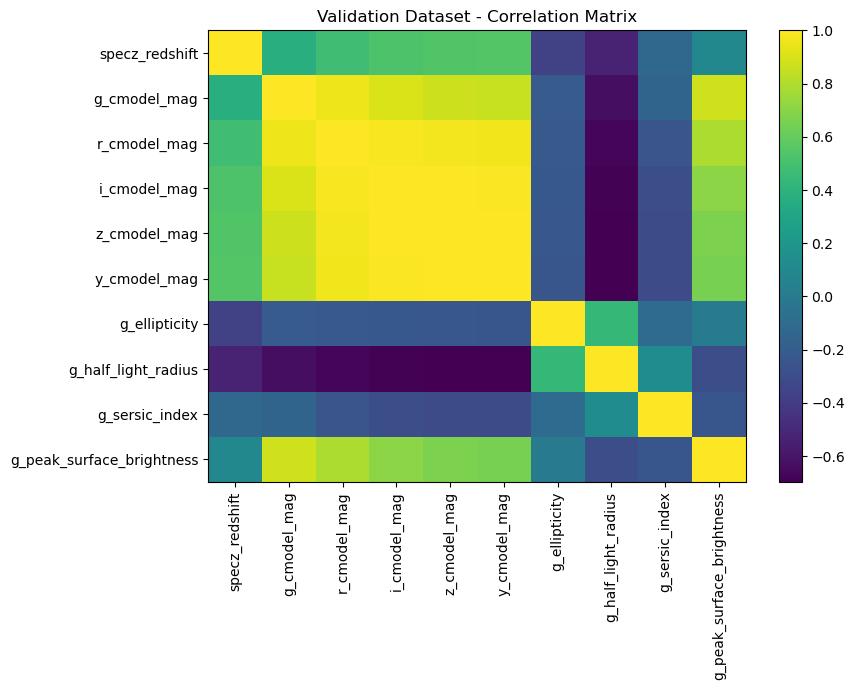

In [26]:
# Select important astronomical features for correlation analysis

corr_features = [
    "specz_redshift",
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    "g_ellipticity",
    "g_half_light_radius",
    "g_sersic_index",
    "g_peak_surface_brightness"
]

# Calculate the correlation matrix

corr_val = df_val[corr_features].corr()


# Visualize correlations between the selected astronomical features

plt.figure(figsize=(9,7))

plt.imshow(corr_val, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr_val.columns)),
    corr_val.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_val.columns)),
    corr_val.columns
)

plt.title("Validation Dataset - Correlation Matrix")

plt.tight_layout()
plt.show()

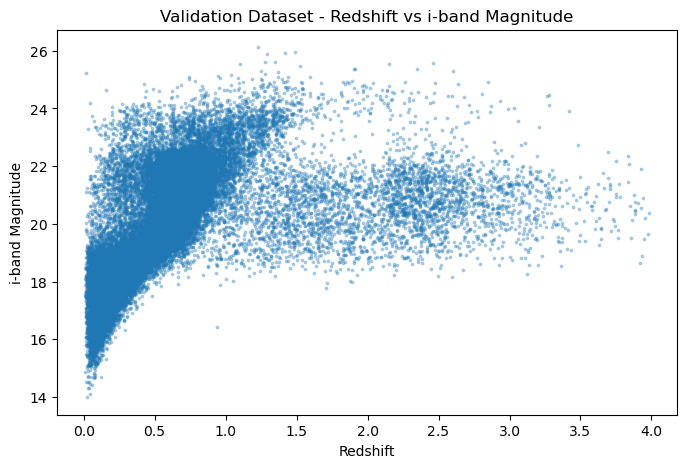

In [27]:
# Examine the relationship between redshift and i-band magnitude

plt.figure(figsize=(8,5))

plt.scatter(
    df_val["specz_redshift"],
    df_val["i_cmodel_mag"],
    s=3,
    alpha=0.3
)

plt.xlabel("Redshift")
plt.ylabel("i-band Magnitude")
plt.title("Validation Dataset - Redshift vs i-band Magnitude")

plt.show()

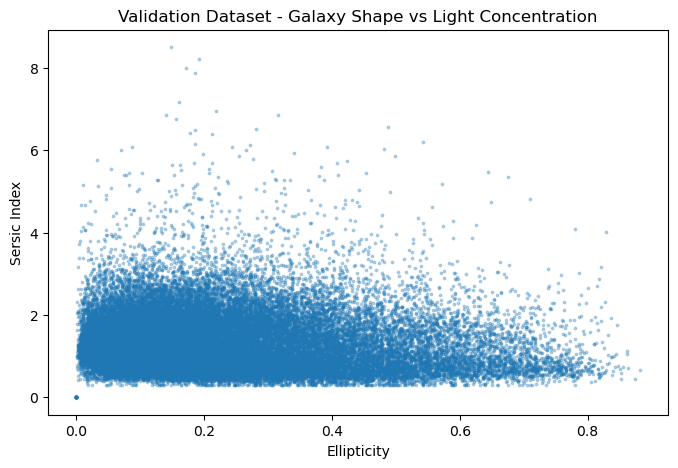

In [28]:
# Examine the relationship between galaxy shape and light concentration

plt.figure(figsize=(8,5))

plt.scatter(
    df_val["g_ellipticity"],
    df_val["g_sersic_index"],
    s=3,
    alpha=0.3
)

plt.xlabel("Ellipticity")
plt.ylabel("Sersic Index")
plt.title("Validation Dataset - Galaxy Shape vs Light Concentration")

plt.show()

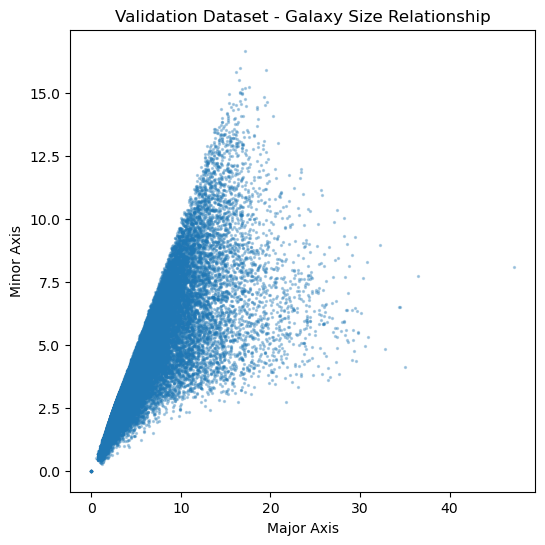

In [29]:
# Examine the relationship between the major and minor axes of galaxies

plt.figure(figsize=(6,6))

plt.scatter(
    df_val["g_major_axis"],
    df_val["g_minor_axis"],
    s=2,
    alpha=0.3
)

plt.xlabel("Major Axis")
plt.ylabel("Minor Axis")
plt.title("Validation Dataset - Galaxy Size Relationship")

plt.show()

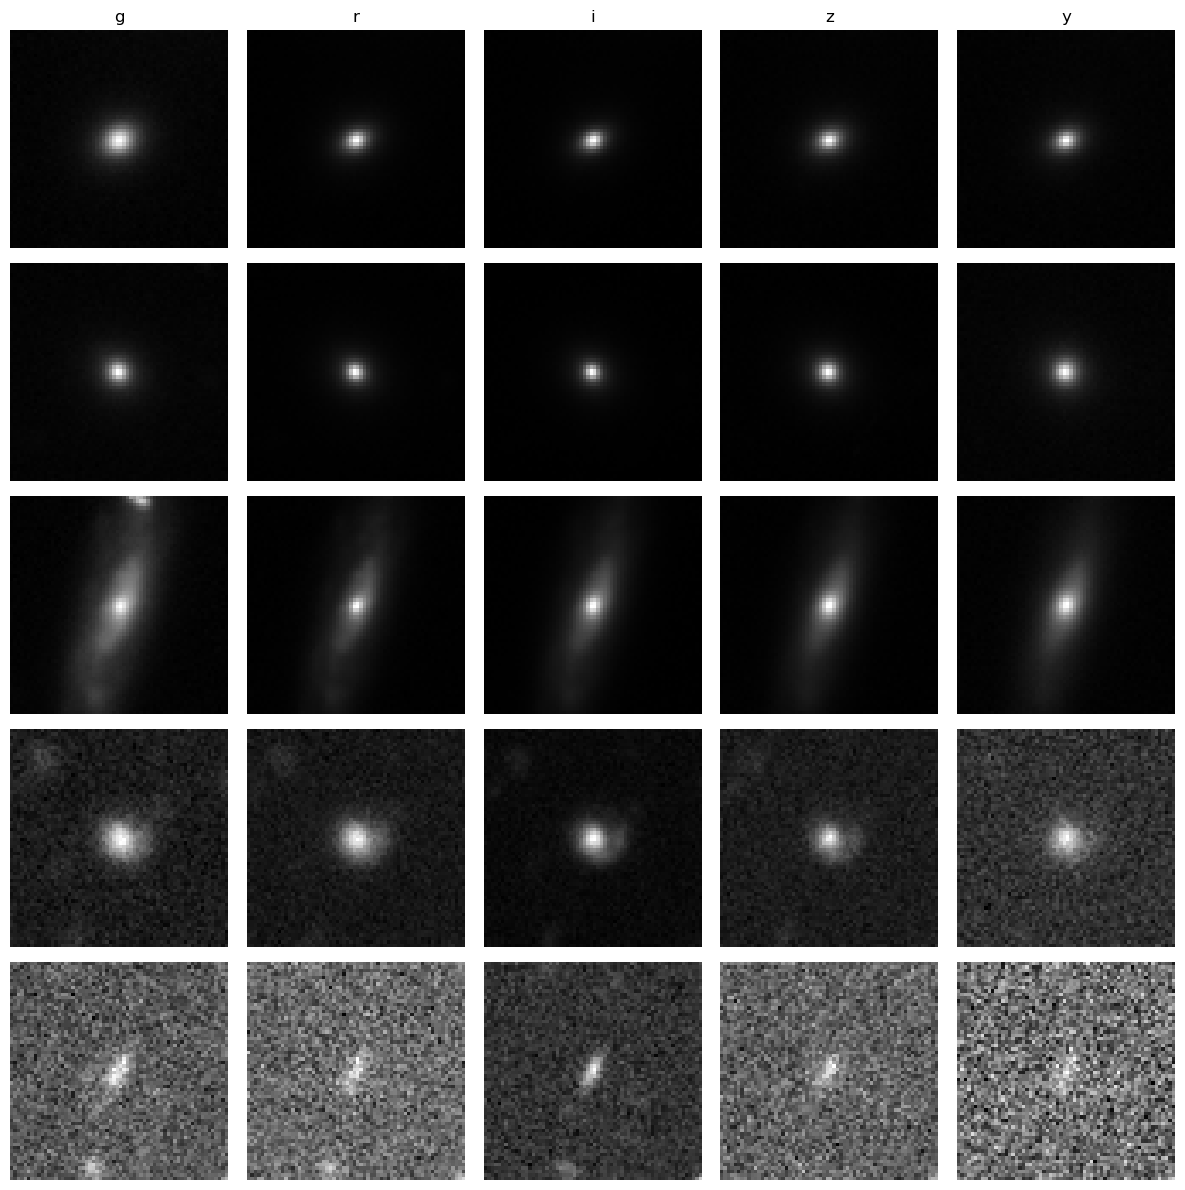

In [32]:
# Select a small number of random galaxies for image visualization
# Only the selected images are loaded to avoid excessive memory usage

with h5py.File(validation_path, "r") as f:
    idx_val = sorted(random.sample(range(len(df_val)), 5))
    images_val = f["image"][idx_val]

# Display the five photometric bands for the selected validation galaxies

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row in range(5):
    for col in range(5):
        axes[row, col].imshow(
            images_val[row, col],
            cmap="gray"
        )
        
        axes[row, col].axis("off")
        
        if row == 0:
            axes[row, col].set_title(bands[col])

plt.tight_layout()
plt.show()

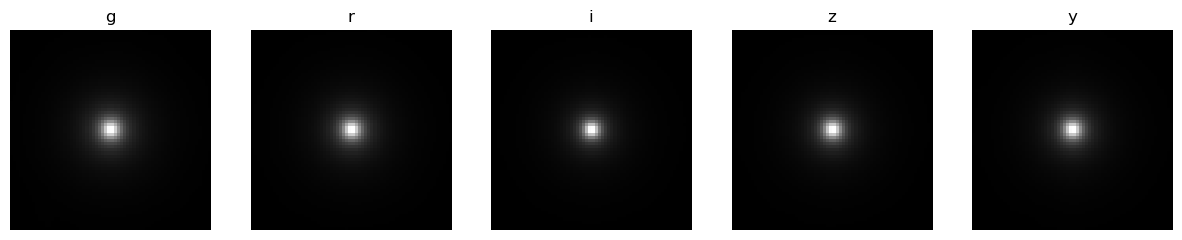

In [33]:
# Calculate the average image for each photometric band
# Images are processed in batches to reduce memory usage

num_val = len(df_val)

mean_band_val = np.zeros((5, 64, 64))

with h5py.File(validation_path, "r") as f:
    images = f["image"]

    for start in range(0, num_val, 500):
        end = min(start + 500, num_val)
        batch = images[start:end]
        
        mean_band_val += batch.sum(axis=0)

mean_band_val /= num_val

# Display the average galaxy image for each photometric band

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, band in enumerate(bands):
    axes[i].imshow(
        mean_band_val[i],
        cmap="gray"
    )
    
    axes[i].set_title(band)
    axes[i].axis("off")

plt.show()

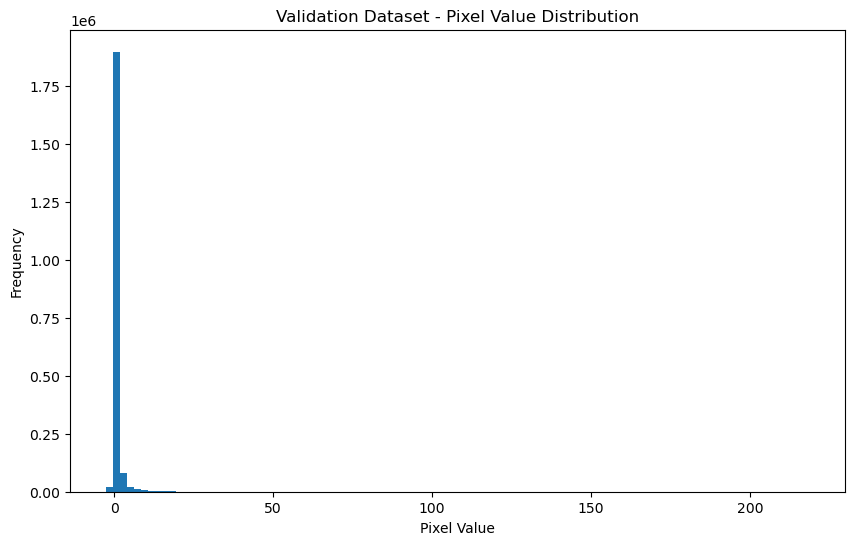

In [35]:
# Load a small sample of validation images to examine pixel values
# Only 100 galaxies are loaded instead of the complete dataset

with h5py.File(validation_path, "r") as f:
    sample_pixels_val = f["image"][:100]

# Plot the distribution of pixel values in the sampled validation images

plt.figure(figsize=(10,6))

plt.hist(
    sample_pixels_val.flatten(),
    bins=100
)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Validation Dataset - Pixel Value Distribution")

plt.show()

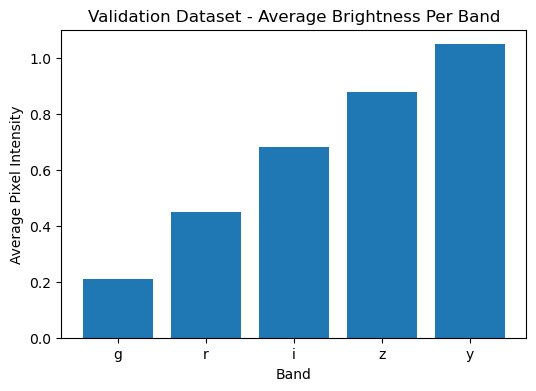

In [36]:
# Calculate the average pixel brightness for each photometric band
# Images are processed in batches to reduce memory usage

band_means_val = []

with h5py.File(validation_path, "r") as f:
    images = f["image"]

    for b in range(5):
        total = 0
        count = 0

        for start in range(0, num_val, 500):
            end = min(start + 500, num_val)
            batch = images[start:end, b]
            
            total += batch.mean()
            count += 1

        band_means_val.append(total / count)

# Compare the average pixel brightness across the five photometric bands

plt.figure(figsize=(6,4))

plt.bar(bands, band_means_val)

plt.xlabel("Band")
plt.ylabel("Average Pixel Intensity")
plt.title("Validation Dataset - Average Brightness Per Band")

plt.show()

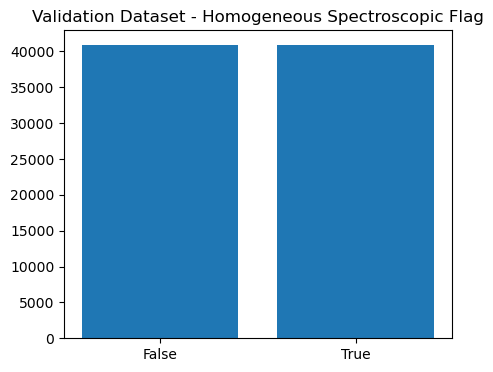

specz_flag_homogeneous
True    40914
Name: count, dtype: int64


In [37]:
# Analyze the distribution of the homogeneous spectroscopic flag

counts_val = df_val["specz_flag_homogeneous"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(
    ["False", "True"],
    counts_val.values
)

plt.title("Validation Dataset - Homogeneous Spectroscopic Flag")

plt.show()

print(counts_val)

In [38]:
# Display the most frequent spectroscopic source names

df_val["specz_name"].value_counts().head(10)

specz_name
b'SDSS-DR12-1237679439348891965'    1
b'SDSS-DR12-1237663784191852614'    1
b'SDSS-DR12-1237663479800529411'    1
b'SDSS-DR12-1237666408436924672'    1
b'SDSS-DR12-1237663462605848915'    1
b'SDSS-DR12-1237663463142654496'    1
b'SDSS-DR12-1237663463142719905'    1
b'SDSS-DR12-1237678617949176496'    1
b'SDSS-DR12-1237663784191787307'    1
b'SDSS-DR12-1237666408436794469'    1
Name: count, dtype: int64

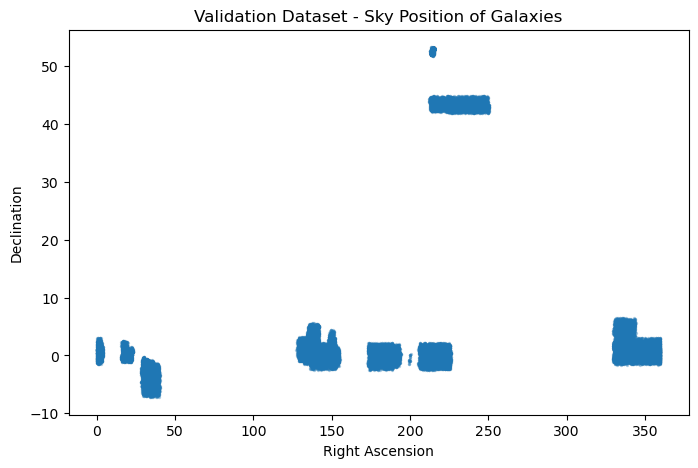

In [40]:

#Sky Coordinates
# Visualize the spatial distribution of validation galaxies
# using right ascension and declination

plt.figure(figsize=(8,5))

plt.scatter(
    df_val["ra"],
    df_val["dec"],
    s=2,
    alpha=0.3
)

plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Validation Dataset - Sky Position of Galaxies")

plt.show()